# Introduction

Google Trends gives us an estimate of search volume. Let's explore if search popularity relates to other kinds of data. Perhaps there are patterns in Google's search volume and the price of Bitcoin or a hot stock like Tesla. Perhaps search volume for the term "Unemployment Benefits" can tell us something about the actual unemployment rate? 

Data Sources: <br>
<ul>
<li> <a href="https://fred.stlouisfed.org/series/UNRATE/">Unemployment Rate from FRED</a></li>
<li> <a href="https://trends.google.com/trends/explore">Google Trends</a> </li>  
<li> <a href="https://finance.yahoo.com/quote/TSLA/history?p=TSLA">Yahoo Finance for Tesla Stock Price</a> </li>    
<li> <a href="https://finance.yahoo.com/quote/BTC-USD/history?p=BTC-USD">Yahoo Finance for Bitcoin Stock Price</a> </li>
</ul>

# Import Statements

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Read the Data

Download and add the .csv files to the same folder as your notebook.

In [3]:
df_tesla = pd.read_csv('TESLA Search Trend vs Price.csv')

df_btc_search = pd.read_csv('Bitcoin Search Trend.csv')
df_btc_price = pd.read_csv('Daily Bitcoin Price.csv')

df_unemployment = pd.read_csv('UE Benefits Search vs UE Rate 2004-19.csv')

# Data Exploration

### Tesla

**Challenge**: <br>
<ul>
<li>What are the shapes of the dataframes? </li>
<li>How many rows and columns? </li>
<li>What are the column names? </li>
<li>Complete the f-string to show the largest/smallest number in the search data column</li> 
<li>Try the <code>.describe()</code> function to see some useful descriptive statistics</li>
<li>What is the periodicity of the time series data (daily, weekly, monthly)? </li>
<li>What does a value of 100 in the Google Trend search popularity actually mean?</li>
</ul>

In [4]:
df_tesla.head()

,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
0,2010-06-01,3,4.766
1,2010-07-01,3,3.988
2,2010-08-01,2,3.896
3,2010-09-01,2,4.082
4,2010-10-01,2,4.368


In [5]:
df_tesla.shape

(124, 3)

In [6]:
df_tesla.columns

Index(['MONTH', 'TSLA_WEB_SEARCH', 'TSLA_USD_CLOSE'], dtype='str')

In [7]:
tesla_largest = df_tesla["TSLA_WEB_SEARCH"].max()
tesla_smallest = df_tesla["TSLA_WEB_SEARCH"].min()

In [8]:
print(f'Largest value for Tesla in Web Search: {tesla_largest}')
print(f'Smallest value for Tesla in Web Search: {tesla_smallest}')

Largest value for Tesla in Web Search: 31
Smallest value for Tesla in Web Search: 2


In [9]:
df_tesla.describe()

,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
count,124.000000,124.000000
mean,8.725806,50.962145
std,5.870332,65.908389
min,2.000000,3.896000
25%,3.750000,7.352500
50%,8.000000,44.653000
75%,12.000000,58.991999
max,31.000000,498.320007


### Unemployment Data

In [10]:
df_unemployment.head()

,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
0,2004-01,34,5.7
1,2004-02,33,5.6
2,2004-03,25,5.8
3,2004-04,29,5.6
4,2004-05,23,5.6


In [11]:
df_unemployment.shape

(181, 3)

In [12]:
df_unemployment.columns

Index(['MONTH', 'UE_BENEFITS_WEB_SEARCH', 'UNRATE'], dtype='str')

In [13]:
df_unemployment.describe()

,UE_BENEFITS_WEB_SEARCH,UNRATE
count,181.000000,181.000000
mean,35.110497,6.217680
std,20.484925,1.891859
min,14.000000,3.700000
25%,21.000000,4.700000
50%,26.000000,5.400000
75%,45.000000,7.800000
max,100.000000,10.000000


In [14]:
print('Largest value for "Unemployemnt Benefits" '
      f'in Web Search: {df_unemployment["UE_BENEFITS_WEB_SEARCH"].max()}')

Largest value for "Unemployemnt Benefits" in Web Search: 100


### Bitcoin

In [15]:
df_btc_price.shape

(2204, 3)

In [16]:
df_btc_price.head()

,DATE,CLOSE,VOLUME
0,2014-09-17,457.334015,21056800.0
1,2014-09-18,424.440002,34483200.0
2,2014-09-19,394.795990,37919700.0
3,2014-09-20,408.903992,36863600.0
4,2014-09-21,398.821014,26580100.0


In [17]:
df_btc_search.shape

(73, 2)

In [18]:
df_btc_search.head()

,MONTH,BTC_NEWS_SEARCH
0,2014-09,5
1,2014-10,4
2,2014-11,4
3,2014-12,4
4,2015-01,5


In [19]:
print(f'largest BTC News Search: {df_btc_search.BTC_NEWS_SEARCH.max()}')

largest BTC News Search: 100


What do the Search Numbers mean?


We can see from our DataFrames that Google's search interest ranges between 0 and 100. But what does that mean? Google defines the values of search interest as: 

Numbers represent search interest relative to the highest point on the chart for the given region and time. A value of 100 is the peak popularity for the term. A value of 50 means that the term is half as popular. A score of 0 means there was not enough data for this term.

Basically, the actual search volume of a term is not publicly available. Google only offers a scaled number. Each data point is divided by the total searches of the geography and time range it represents to compare relative popularity.



For each word in your search, Google finds how much search volume in each region and time period your term had relative to all the searches in that region and time period. It then combines all of these measures into a single measure of popularity, and then it scales the values across your topics, so the largest measure is set to 100. In short: Google Trends doesn’t exactly tell you how many searches occurred for your topic, but it does give you a nice proxy.

Here are the Google Trends Search Parameters that I used to generate the .csv data:

"Tesla", Worldwide, Web Search

"Bitcoin", Worldwide, News Search

"Unemployment Benefits", United States, Web Search

# Data Cleaning

### Check for Missing Values

**Challenge**: Are there any missing values in any of the dataframes? If so, which row/rows have missing values? How many missing values are there?

In [20]:
print(f'Missing values for Tesla?: {df_tesla.isna().values.any()}')
print(f'Missing values for U/E?: {df_unemployment.isna().values.any()}')
print(f'Missing values for BTC Search?: {df_btc_search.isna().values.any()}')

Missing values for Tesla?: False
Missing values for U/E?: False
Missing values for BTC Search?: False


In [21]:
print(f'Missing values for BTC price?: {df_btc_price.isna().values.any()}')

Missing values for BTC price?: True


In [22]:
print(f'Number of missing values: {df_btc_price.isna().values.sum()}')

Number of missing values: 2


Because isna() turns the DataFrame into True and False values:

```
df_btc_price.isna().values
```

might produce:

```
array([
    [False, False, False],
    [False,  True, False],
    [False,  True, False],
])
```

Then .sum() sums that whole NumPy array. In Python math:

```
True == 1
False == 0
```

So it effectively calculates:

```
0 + 0 + 0 + 0 + 1 + 0 + 0 + 1 + 0
```

Result:

```
2
```

It “knows” what to sum because `.values` is an array containing only booleans, and NumPy treats `True` as `1` and `False` as `0` during addition.

**Challenge**: Remove any missing values that you found. 

In [23]:
df_btc_price[df_btc_price.CLOSE.isna()]

,DATE,CLOSE,VOLUME
2148,2020-08-04,NaN,NaN


In [24]:
df_btc_price.dropna(inplace=True) # equivalent to df_btc_price = df_btc_price.dropna()

### Convert Strings to DateTime Objects

**Challenge**: Check the data type of the entries in the DataFrame MONTH or DATE columns. Convert any strings in to Datetime objects. Do this for all 4 DataFrames. Double check if your type conversion was successful.

In [25]:
df_tesla["MONTH"] = pd.to_datetime(df_tesla["MONTH"])
df_tesla.info()

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   MONTH            124 non-null    datetime64[us]
 1   TSLA_WEB_SEARCH  124 non-null    int64         
 2   TSLA_USD_CLOSE   124 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 3.0 KB


`pd.to_datetime(df_tesla["MONTH"])` does convert the dates, but it returns the converted result instead of changing the original column.

In [26]:
df_unemployment.MONTH = pd.to_datetime(df_unemployment["MONTH"])
df_unemployment.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   MONTH                   181 non-null    datetime64[us]
 1   UE_BENEFITS_WEB_SEARCH  181 non-null    int64         
 2   UNRATE                  181 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 4.4 KB


In [27]:
df_btc_price.DATE = pd.to_datetime(df_btc_price["DATE"])
df_btc_price.info()

<class 'pandas.DataFrame'>
Index: 2203 entries, 0 to 2203
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    2203 non-null   datetime64[us]
 1   CLOSE   2203 non-null   float64       
 2   VOLUME  2203 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 68.8 KB


In [28]:
df_btc_search.MONTH = pd.to_datetime(df_btc_search["MONTH"])
df_btc_search.info()

<class 'pandas.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   MONTH            73 non-null     datetime64[us]
 1   BTC_NEWS_SEARCH  73 non-null     int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 1.3 KB


### Converting from Daily to Monthly Data

[Pandas .resample() documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.resample.html) <br>

Next, we have to think about how to make our Bitcoin price and our Bitcoin search volume comparable. Our Bitcoin price is daily data, but our Bitcoin Search Popularity is monthly data.

To convert our daily data into monthly data, we're going to use the `.resample()` function. The only things we need to specify is which column to use (i.e., our DATE column) and what kind of sample frequency we want (i.e., the "rule"). We want a monthly frequency, so we use 'M'.

After resampling, we need to figure out how the data should be treated. In our case, we want the last available price of the month - the price at month-end.
```python
df_btc_monthly = df_btc_price.resample('M', on='DATE').last()
```

If we wanted the average price over the course of the month, we could use something like:
```python
df_btc_monthly = df_btc_price.resample('M', on='DATE').mean()
```

In [29]:
df_btc_monthly = df_btc_price.resample('ME', on='DATE').last()

In [30]:
df_btc_monthly.head()

,CLOSE,VOLUME
DATE,,
2014-09-30,386.944000,34707300.0
2014-10-31,338.321014,12545400.0
2014-11-30,378.046997,9194440.0
2014-12-31,320.192993,13942900.0
2015-01-31,217.464005,23348200.0


# Data Visualisation

### Notebook Formatting & Style Helpers

In [31]:
# Create locators for ticks on the time axis
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter("%Y")

In [32]:
# Register date converters to avoid warning messages
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

### Tesla Stock Price v.s. Search Volume

**Challenge:** Plot the Tesla stock price against the Tesla search volume using a line chart and two different axes. Label one axis 'TSLA Stock Price' and the other 'Search Trend'. 

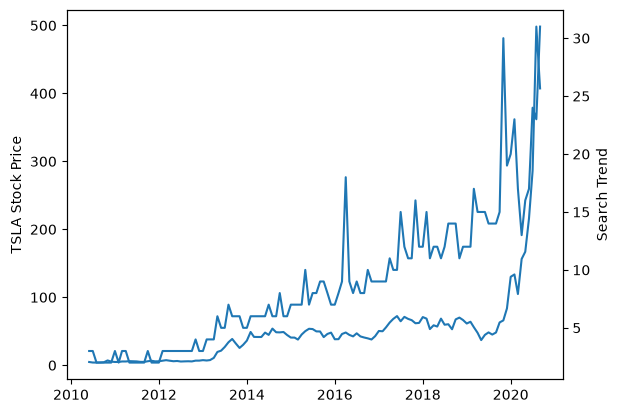

In [33]:
ax1 = plt.gca() # get current axes
ax2 = ax1.twinx() # create another axis that shares the same x-axis

ax1.set_ylabel('TSLA Stock Price')
ax2.set_ylabel('Search Trend')

ax1.plot(df_tesla.MONTH, df_tesla.TSLA_USD_CLOSE)
ax2.plot(df_tesla.MONTH, df_tesla.TSLA_WEB_SEARCH)

**Challenge**: Add colours to style the chart. This will help differentiate the two lines and the axis labels. Try using one of the blue [colour names](https://matplotlib.org/3.1.1/gallery/color/named_colors.html) for the search volume and a HEX code for a red colour for the stock price. 
<br>
<br>
Hint: you can colour both the [axis labels](https://matplotlib.org/3.3.2/api/text_api.html#matplotlib.text.Text) and the [lines](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.lines.Line2D.html#matplotlib.lines.Line2D) on the chart using keyword arguments (kwargs).  

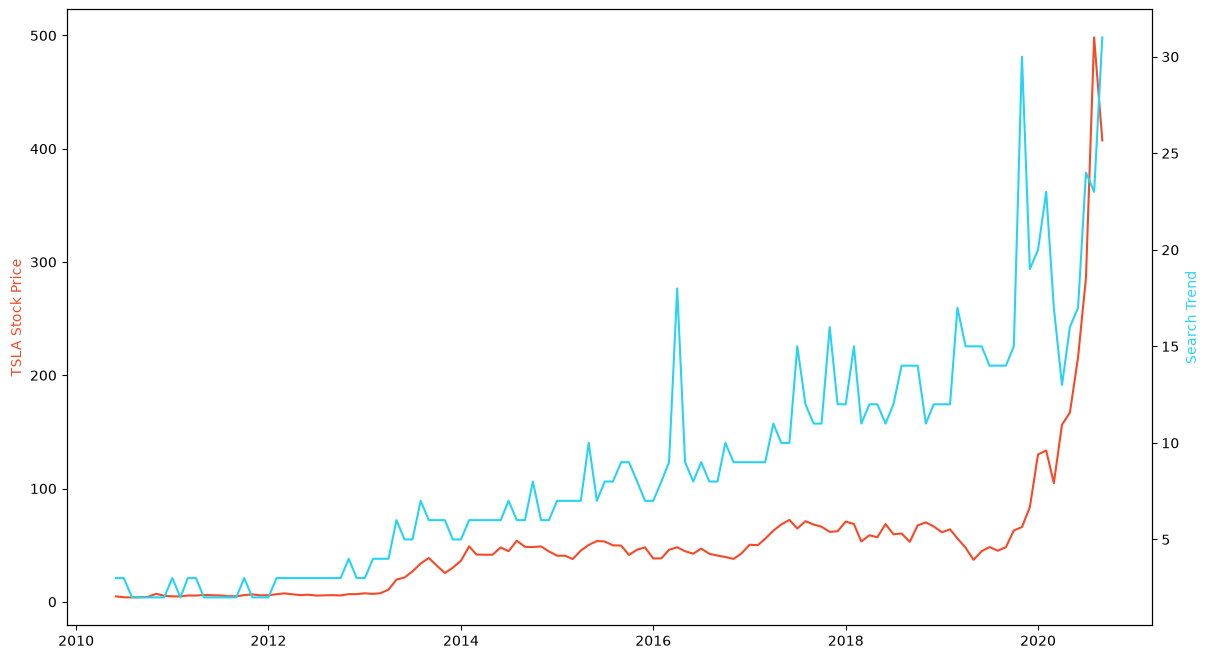

In [34]:
plt.figure(figsize=(14, 8))

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('TSLA Stock Price', color='#F54927')
ax2.set_ylabel('Search Trend', color='#27D3F5')
ax1.plot(df_tesla.MONTH, df_tesla.TSLA_USD_CLOSE, color='#F54927')
ax2.plot(df_tesla.MONTH, df_tesla.TSLA_WEB_SEARCH, color='#27D3F5')

**Challenge**: Make the chart larger and easier to read. 
1. Increase the figure size (e.g., to 14 by 8). 
2. Increase the font sizes for the labels and the ticks on the x-axis to 14. 
3. Rotate the text on the x-axis by 45 degrees. 
4. Make the lines on the chart thicker. 
5. Add a title that reads 'Tesla Web Search vs Price'
6. Keep the chart looking sharp by changing the dots-per-inch or [DPI value](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.figure.html). 
7. Set minimum and maximum values for the y and x axis. Hint: check out methods like [set_xlim()](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.set_xlim.html). 
8. Finally use [plt.show()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.show.html) to display the chart below the cell instead of relying on the automatic notebook output.

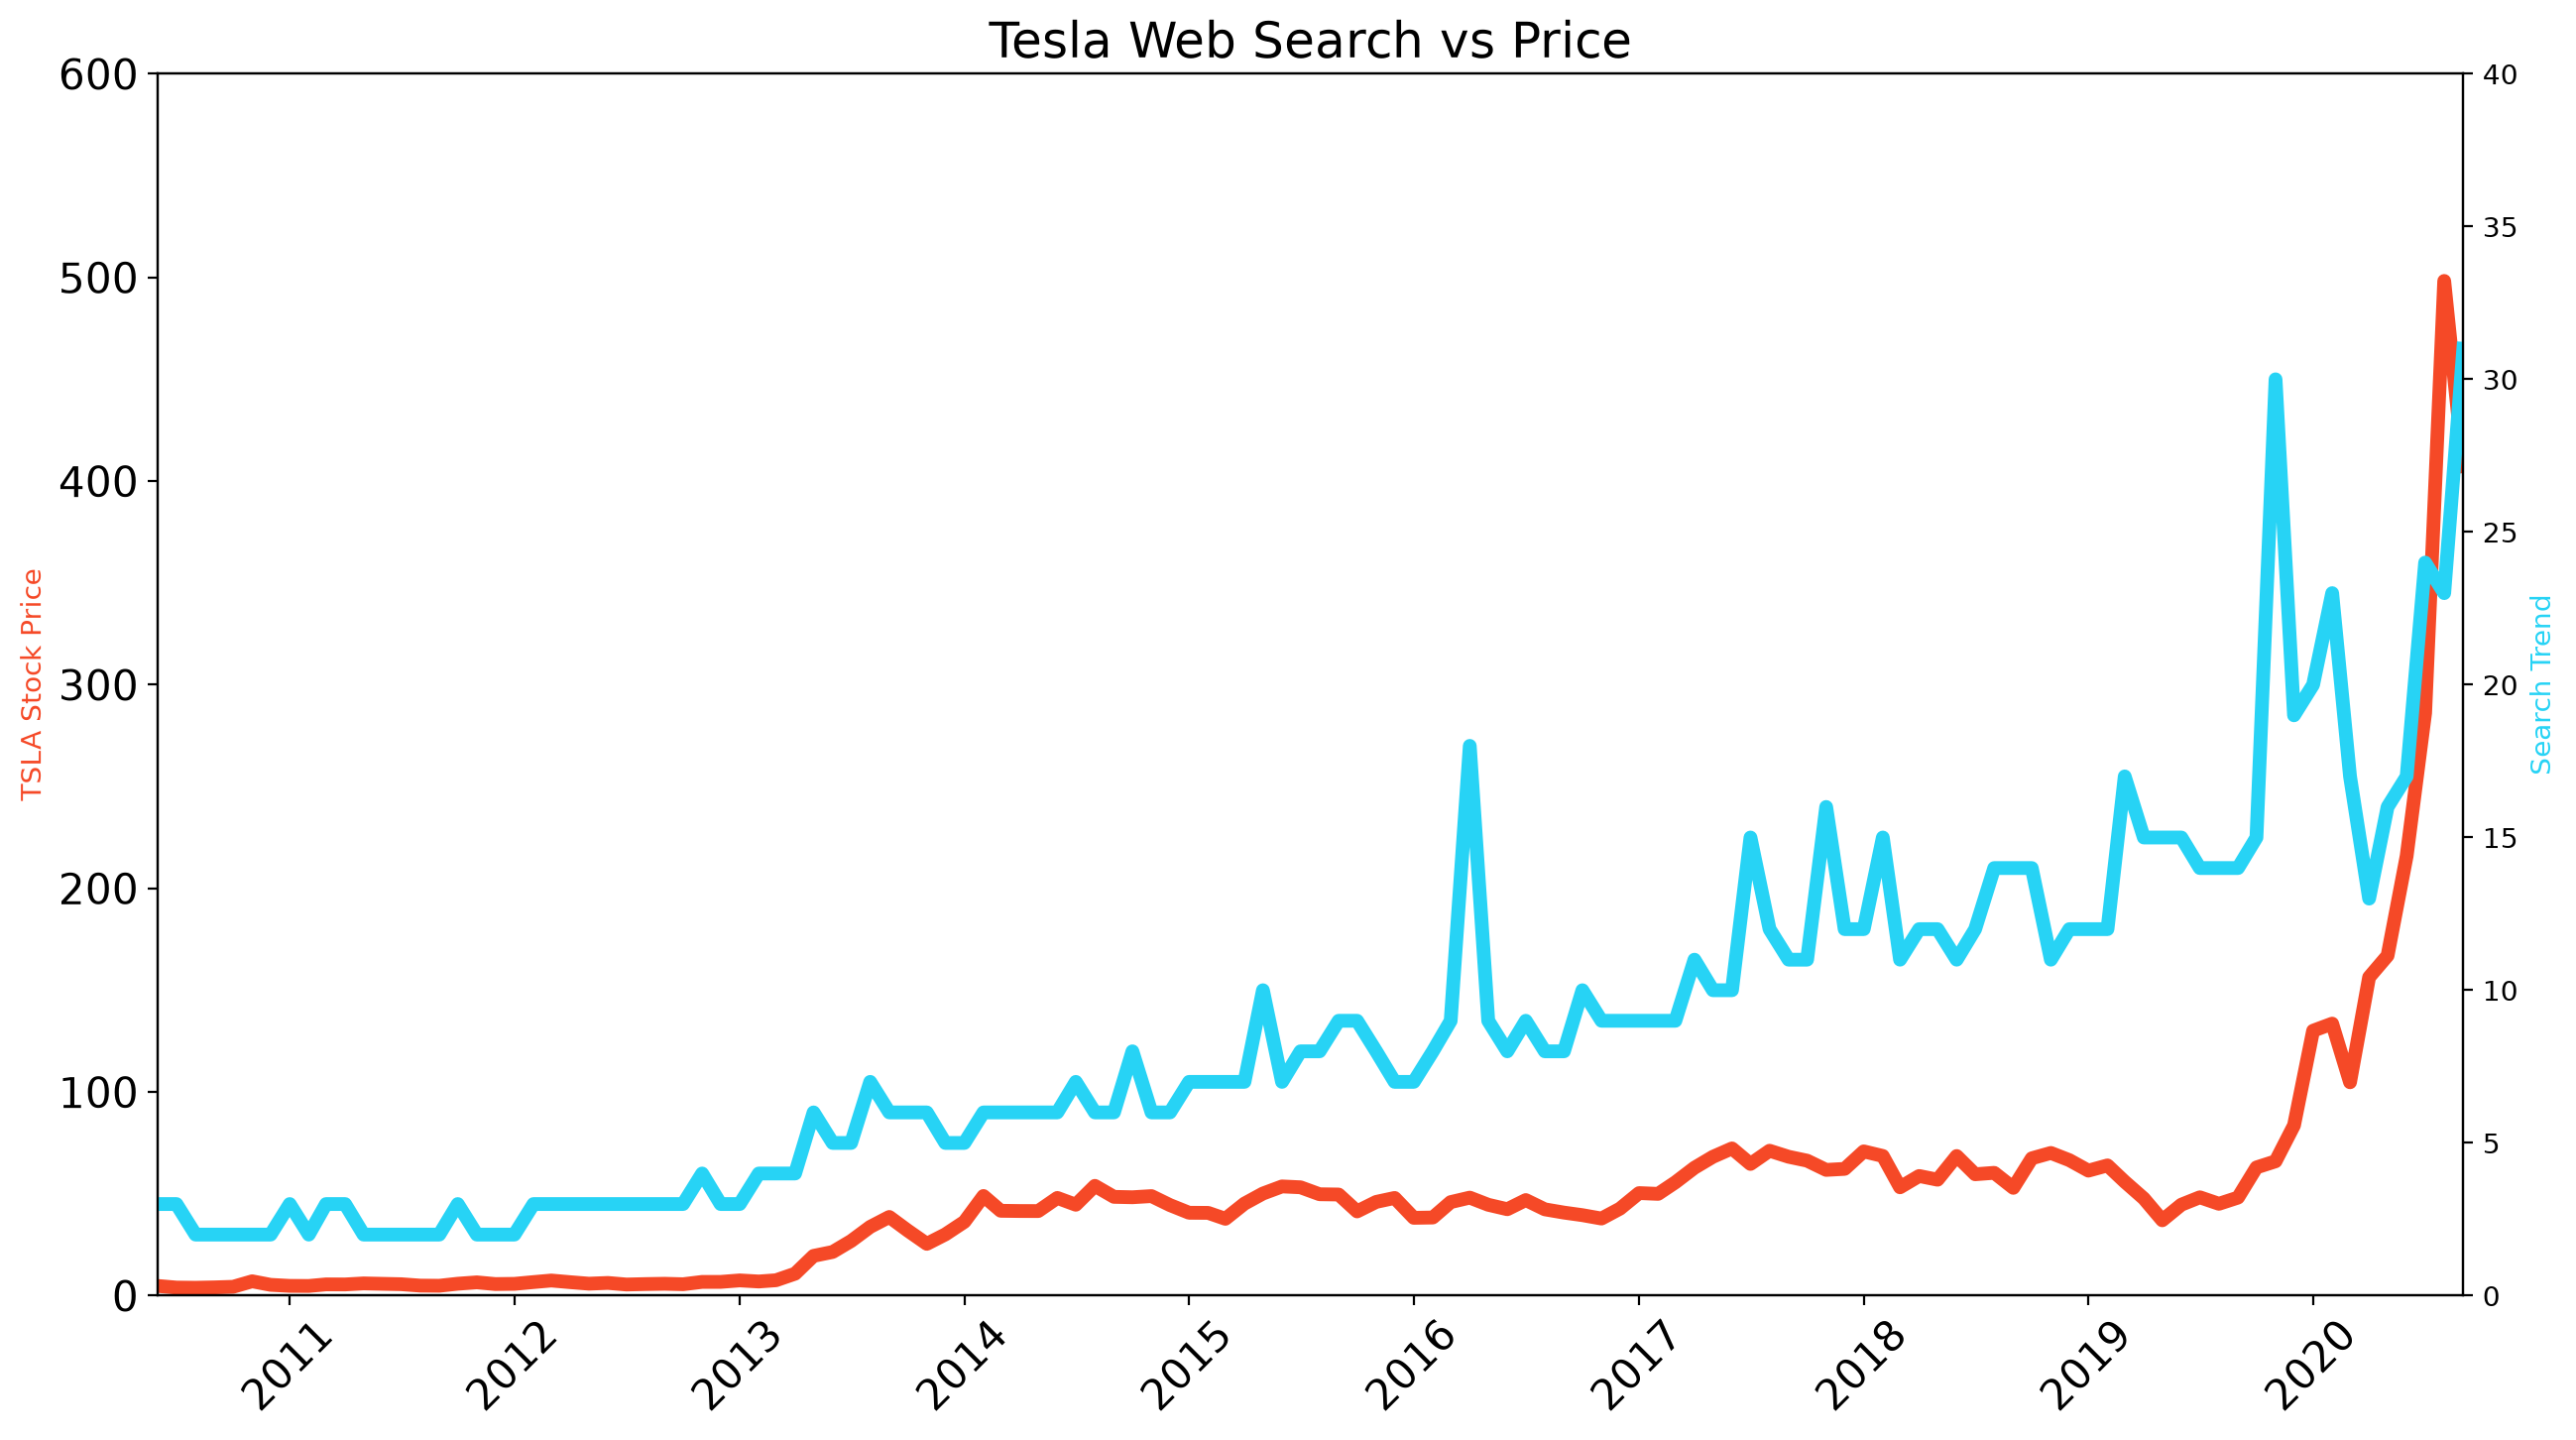

In [35]:
plt.figure(figsize=(15, 8), dpi=200.0)
plt.xticks(fontsize=15, rotation=45)
plt.yticks(fontsize=15)
plt.title("Tesla Web Search vs Price", fontsize=18)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('TSLA Stock Price', color='#F54927')
ax2.set_ylabel('Search Trend', color='#27D3F5')
ax1.set_xlim([df_tesla.MONTH.min(), df_tesla.MONTH.max()])
ax1.set_ylim([0, 600])
ax2.set_ylim([0, 40])
ax1.plot(df_tesla.MONTH, df_tesla.TSLA_USD_CLOSE, color='#F54927', linewidth=5)
ax2.plot(df_tesla.MONTH, df_tesla.TSLA_WEB_SEARCH, color='#27D3F5',linewidth=5)

plt.show()

How to add tick formatting for dates on the x-axis. 

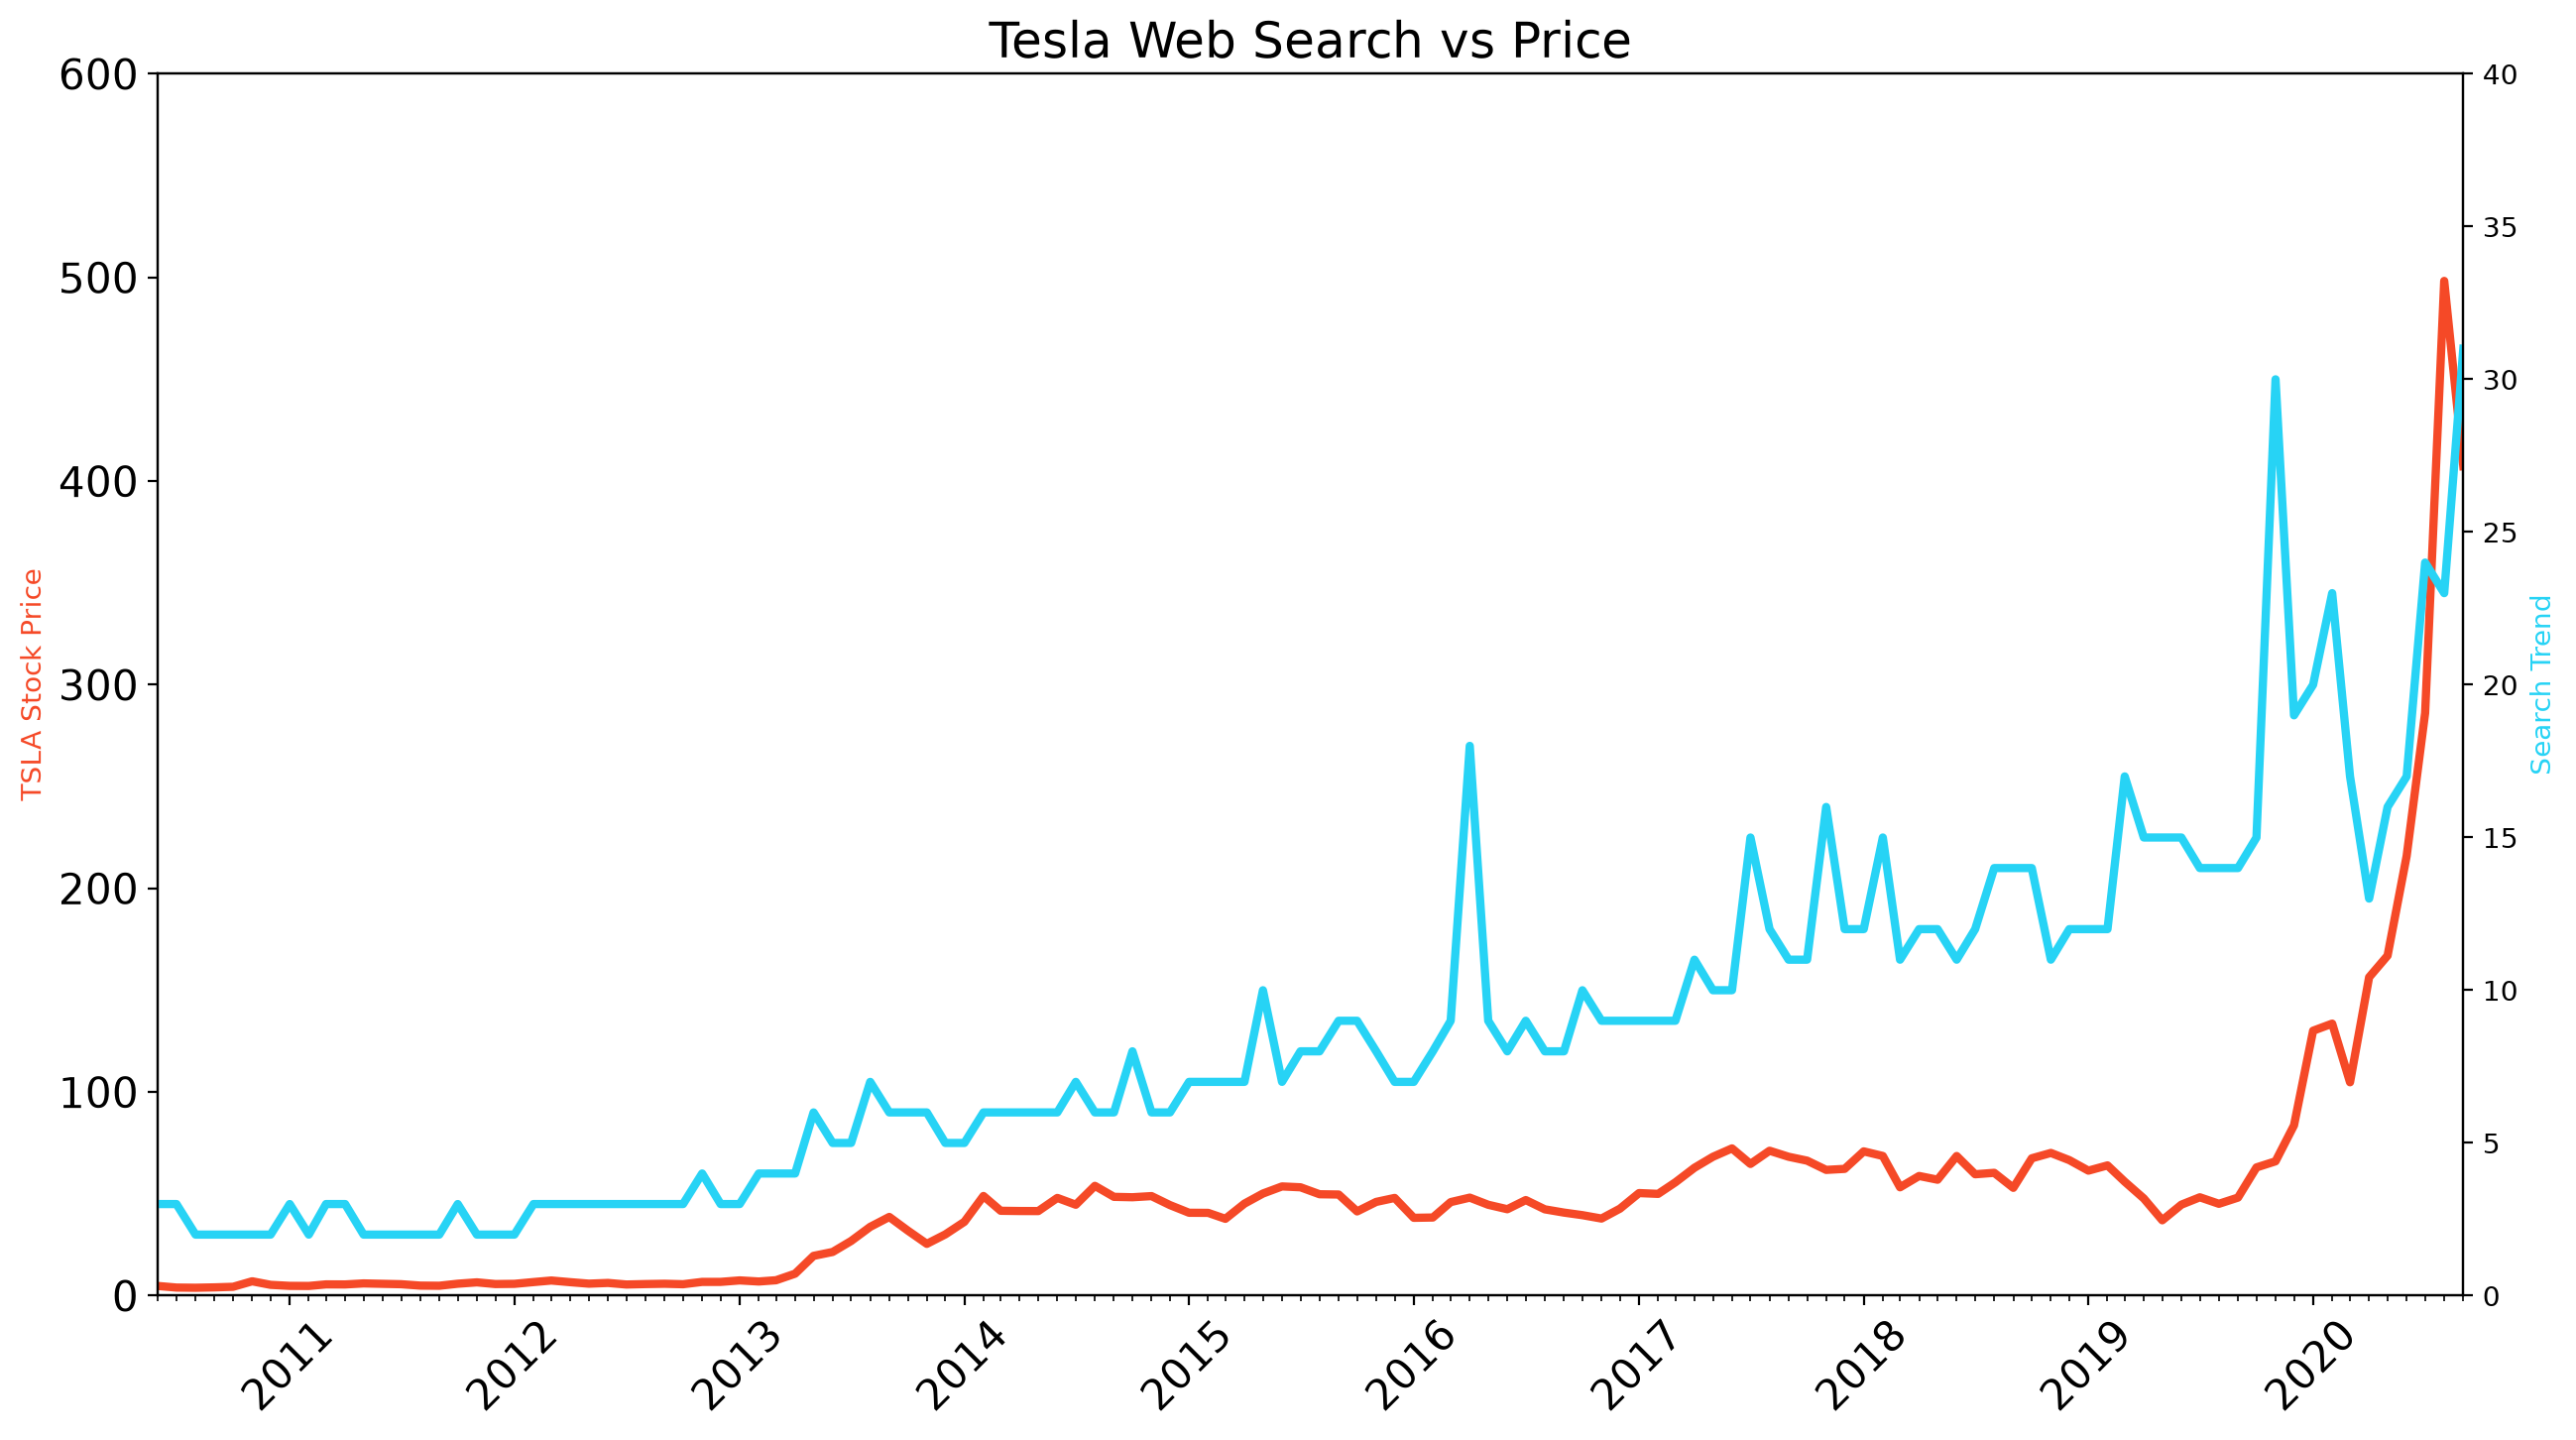

In [36]:
plt.figure(figsize=(15, 8), dpi=200.0)
plt.xticks(fontsize=15, rotation=45)
plt.yticks(fontsize=15)
plt.title("Tesla Web Search vs Price", fontsize=18)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('TSLA Stock Price', color='#F54927')
ax2.set_ylabel('Search Trend', color='#27D3F5')
ax1.set_xlim([df_tesla.MONTH.min(), df_tesla.MONTH.max()])
ax1.set_ylim([0, 600])
ax2.set_ylim([0, 40])
ax1.plot(df_tesla.MONTH, df_tesla.TSLA_USD_CLOSE, color='#F54927', linewidth=3)
ax2.plot(df_tesla.MONTH, df_tesla.TSLA_WEB_SEARCH, color='#27D3F5',linewidth=3)

ax1.xaxis.set_major_locator(years) # Uses your years rule in years = mdates.YearLocator() to create major tick at each year (2011, 2012, etc.)
ax1.xaxis.set_major_formatter(years_fmt) # Uses your formatting rule in years_fmt = mdates.DateFormatter("%Y") so those major ticks display as just the year (2011, 2012, etc.) instead of full dates like 2011-01-01, 2012-01-01, etc
ax1.xaxis.set_minor_locator(months) # Uses months = mdates.MonthLocator() to place smaller, usually unlabeled ticks for each month between the labeled year ticks.

plt.show()

### Bitcoin (BTC) Price v.s. Search Volume

**Challenge**: Create the same chart for the Bitcoin Prices vs. Search volumes. <br>
1. Modify the chart title to read 'Bitcoin News Search vs Resampled Price' <br>
2. Change the y-axis label to 'BTC Price' <br>
3. Change the y- and x-axis limits to improve the appearance <br>
4. Investigate the [linestyles](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html ) to make the BTC price a dashed line <br>
5. Investigate the [marker types](https://matplotlib.org/3.2.1/api/markers_api.html) to make the search datapoints little circles <br>
6. Were big increases in searches for Bitcoin accompanied by big increases in the price?

In [37]:
df_btc_price.head()

,DATE,CLOSE,VOLUME
0,2014-09-17,457.334015,21056800.0
1,2014-09-18,424.440002,34483200.0
2,2014-09-19,394.795990,37919700.0
3,2014-09-20,408.903992,36863600.0
4,2014-09-21,398.821014,26580100.0


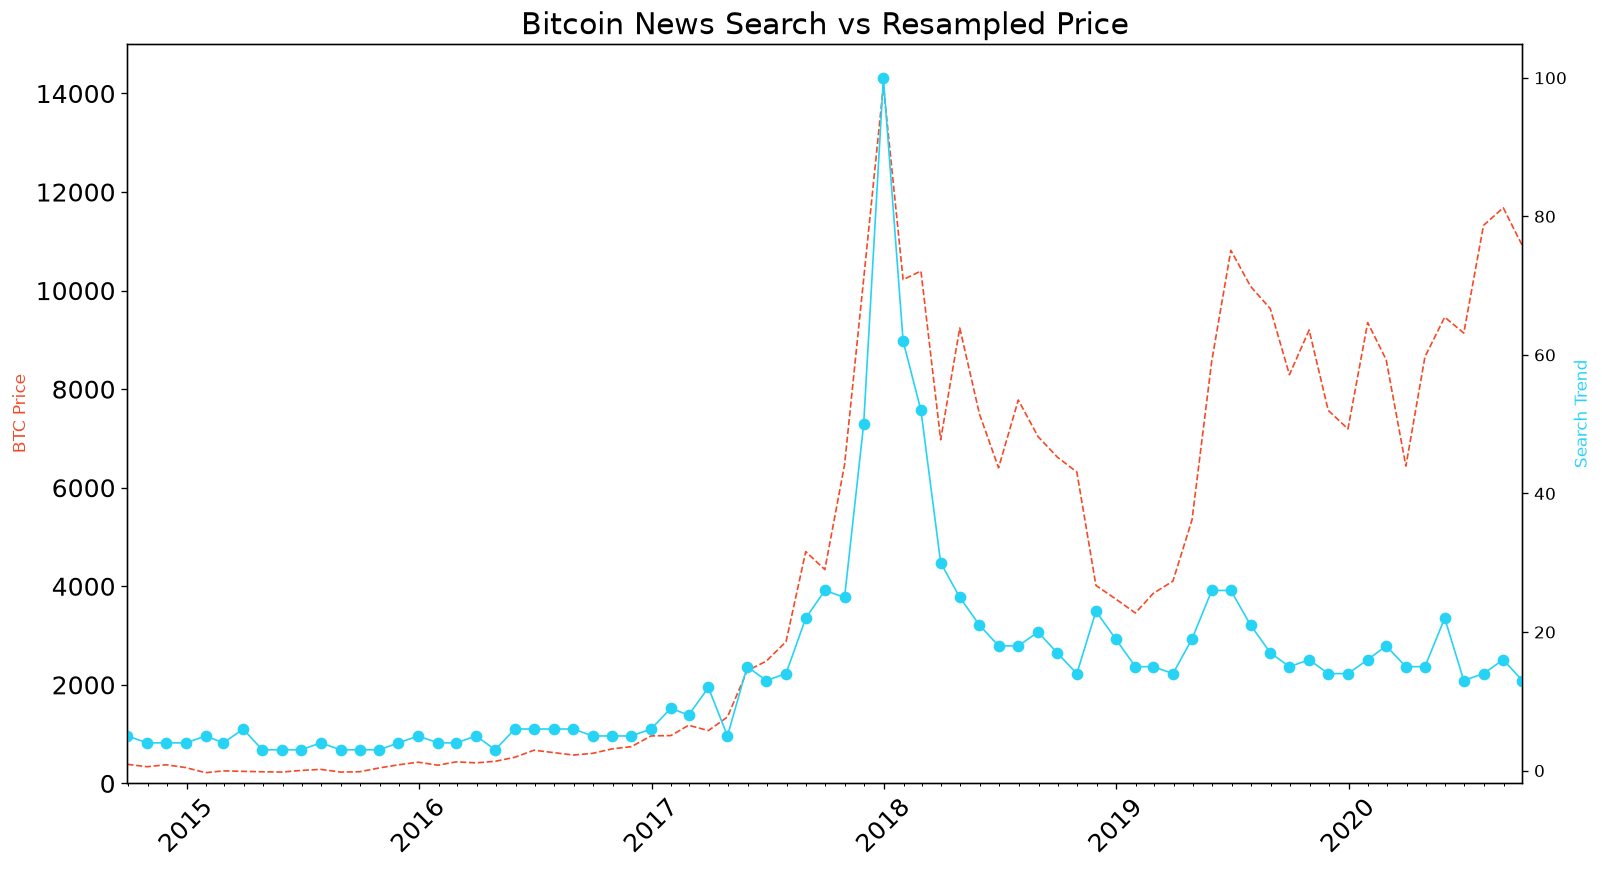

In [46]:
plt.figure(figsize=(15, 8), dpi=120.0)
plt.xticks(fontsize=15, rotation=45)
plt.yticks(fontsize=15)
plt.title("Bitcoin News Search vs Resampled Price", fontsize=18)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('BTC Price', color='#F54927')
ax2.set_ylabel('Search Trend', color='#27D3F5')
ax1.set_xlim([df_btc_monthly.index.min(), df_btc_monthly.index.max()])
ax1.set_ylim([0, 15000])
ax1.plot(df_btc_monthly.index, df_btc_monthly.CLOSE, color='#F54927', linewidth=1, linestyle='dashed')
ax2.plot(df_btc_monthly.index, df_btc_search.BTC_NEWS_SEARCH, color='#27D3F5',linewidth=1, marker="o")

ax1.xaxis.set_major_locator(years) # Uses your years rule in years = mdates.YearLocator() to create major tick at each year (2011, 2012, etc.)
ax1.xaxis.set_major_formatter(years_fmt) # Uses your formatting rule in years_fmt = mdates.DateFormatter("%Y") so those major ticks display as just the year (2011, 2012, etc.) instead of full dates like 2011-01-01, 2012-01-01, etc
ax1.xaxis.set_minor_locator(months) # Uses months = mdates.MonthLocator() to place smaller, usually unlabeled ticks for each month between the labeled year ticks.

plt.show()

### Unemployement Benefits Search vs. Actual Unemployment in the U.S.

**Challenge** Plot the search for "unemployment benefits" against the unemployment rate. 
1. Change the title to: Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate <br>
2. Change the y-axis label to: FRED U/E Rate <br>
3. Change the axis limits <br>
4. Add a grey [grid](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.grid.html) to the chart to better see the years and the U/E rate values. Use dashes for the line style<br> 
5. Can you discern any seasonality in the searches? Is there a pattern? 

In [39]:
df_unemployment

,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
0,2004-01-01,34,5.7
1,2004-02-01,33,5.6
2,2004-03-01,25,5.8
3,2004-04-01,29,5.6
4,2004-05-01,23,5.6
...,...,...,...
176,2018-09-01,14,3.7
177,2018-10-01,15,3.8
178,2018-11-01,16,3.7
179,2018-12-01,17,3.9


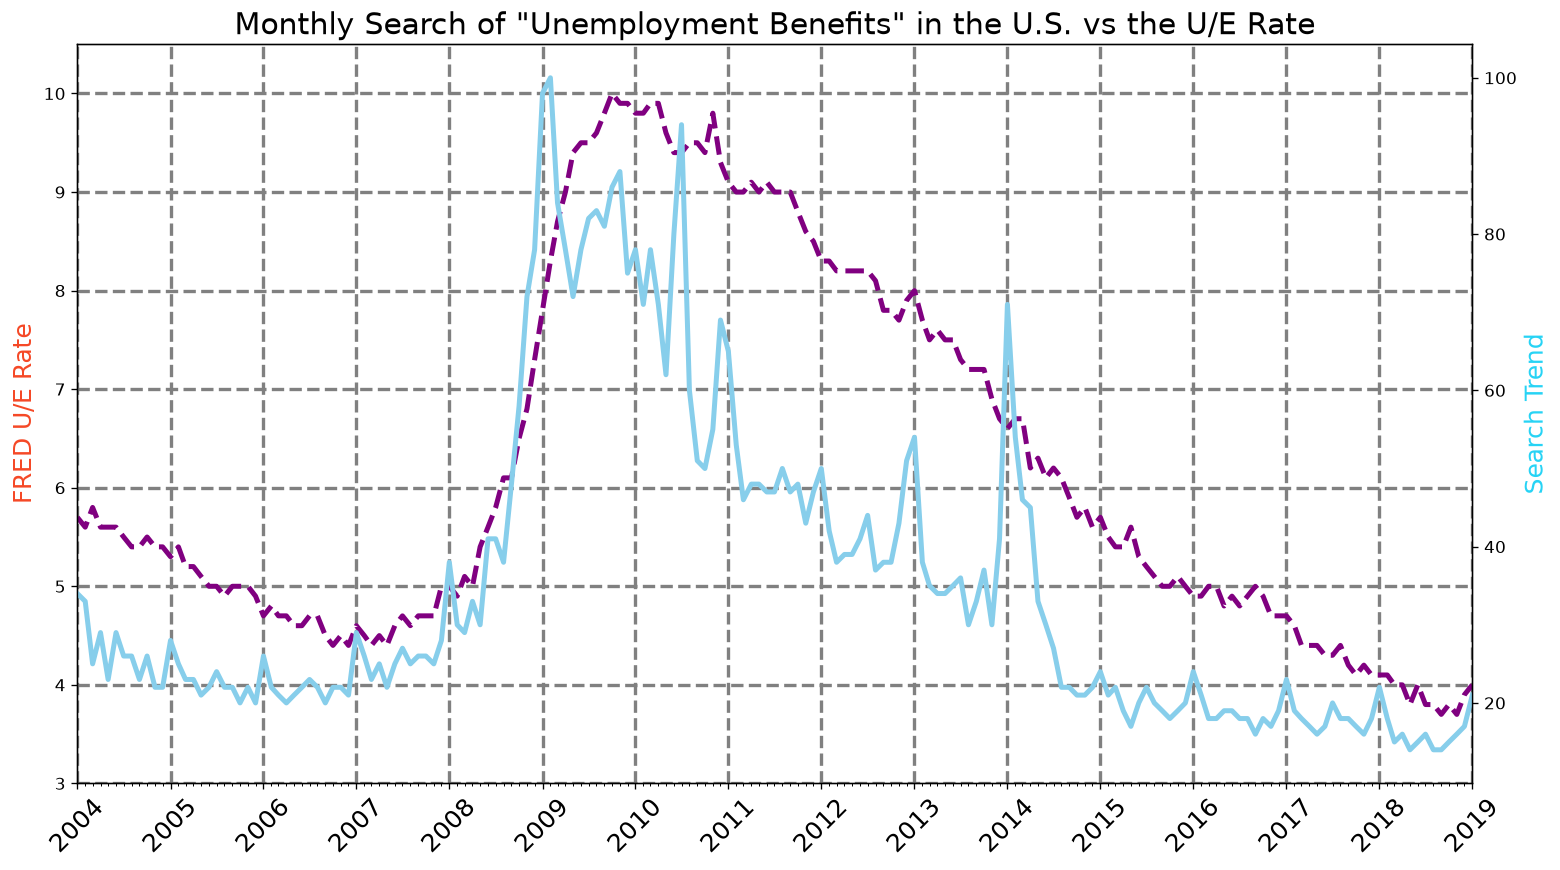

In [55]:
plt.figure(figsize=(15, 8), dpi=120.0)
plt.xticks(fontsize=15, rotation=45)

plt.title('Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate', fontsize=18)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('FRED U/E Rate', color='#F54927', fontsize=15)
ax2.set_ylabel('Search Trend', color='#27D3F5', fontsize=15)
ax1.set_xlim([df_unemployment.MONTH.min(), df_unemployment.MONTH.max()])
ax1.set_ylim(bottom=3, top=10.5)
ax1.plot(df_unemployment.MONTH, df_unemployment.UNRATE, color='purple', linewidth=3, linestyle='--')
ax2.plot(df_unemployment.MONTH, df_unemployment.UE_BENEFITS_WEB_SEARCH, color='skyblue',linewidth=3)

ax1.xaxis.set_major_locator(years) # Uses your years rule in years = mdates.YearLocator() to create major tick at each year (2011, 2012, etc.)
ax1.xaxis.set_major_formatter(years_fmt) # Uses your formatting rule in years_fmt = mdates.DateFormatter("%Y") so those major ticks display as just the year (2011, 2012, etc.) instead of full dates like 2011-01-01, 2012-01-01, etc
ax1.xaxis.set_minor_locator(months) # Uses months = mdates.MonthLocator() to place smaller, usually unlabeled ticks for each month between the labeled year ticks.
ax1.grid(visible=True, color='grey', linestyle='--', linewidth=2)
plt.show()

**Challenge**: Calculate the 3-month or 6-month rolling average for the web searches. Plot the 6-month rolling average search data against the actual unemployment. What do you see in the chart? Which line moves first?


In [60]:
roll_df = df_unemployment[['UE_BENEFITS_WEB_SEARCH', 'UNRATE']].rolling(window=6).mean()

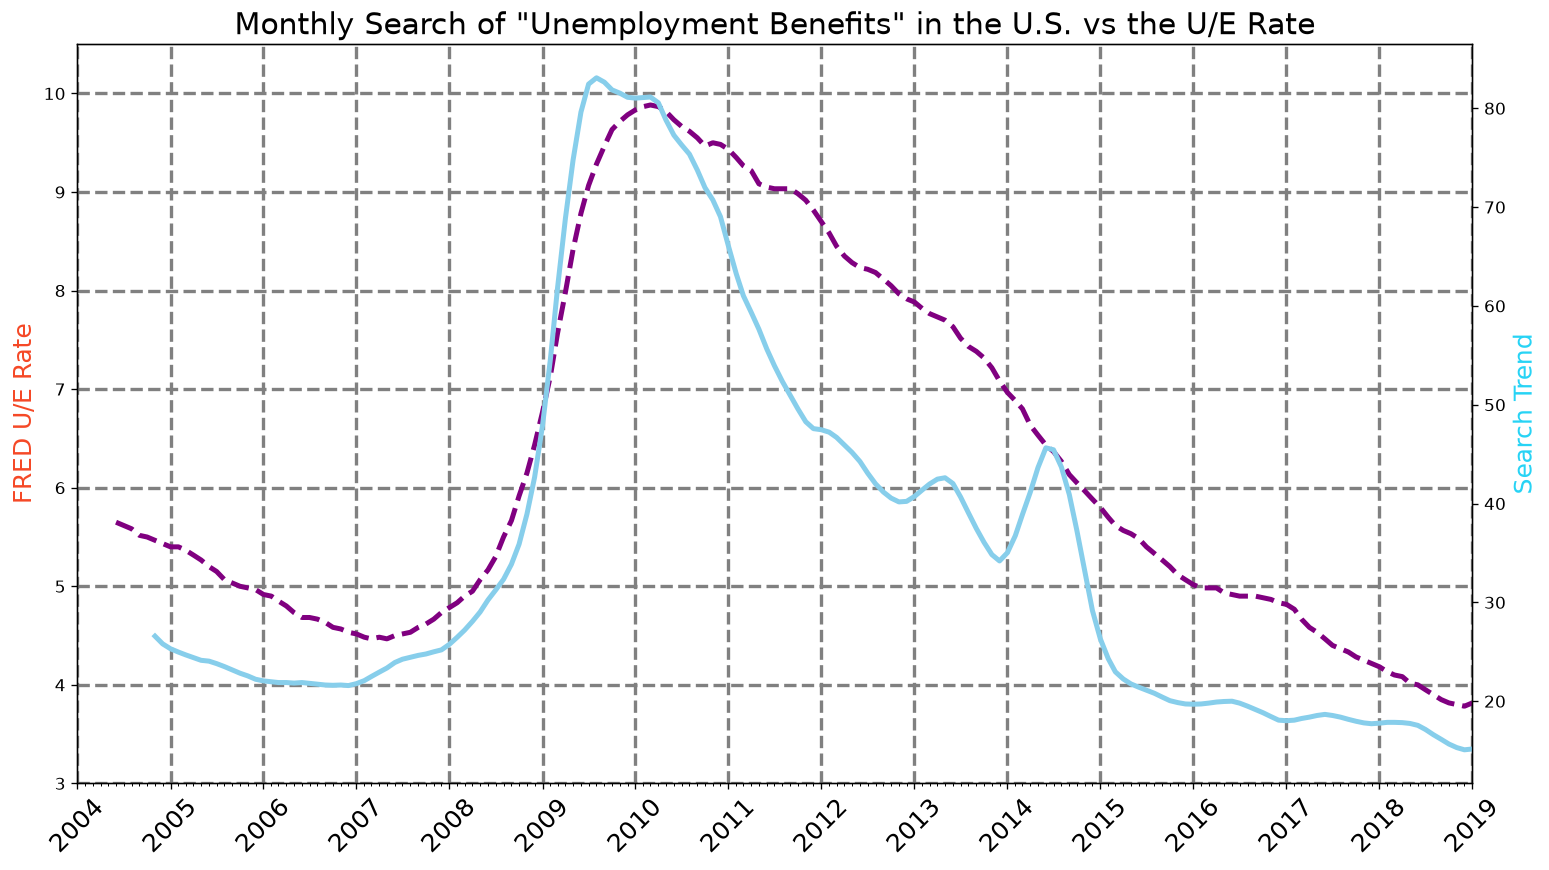

In [62]:
plt.figure(figsize=(15, 8), dpi=120.0)
plt.xticks(fontsize=15, rotation=45)

plt.title('Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate', fontsize=18)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('FRED U/E Rate', color='#F54927', fontsize=15)
ax2.set_ylabel('Search Trend', color='#27D3F5', fontsize=15)
ax1.set_xlim([df_unemployment.MONTH.min(), df_unemployment.MONTH.max()])
ax1.set_ylim(bottom=3, top=10.5)
ax1.plot(df_unemployment.MONTH, roll_df.UNRATE, color='purple', linewidth=3, linestyle='--')
ax2.plot(df_unemployment.MONTH, roll_df.UE_BENEFITS_WEB_SEARCH, color='skyblue',linewidth=3)

ax1.xaxis.set_major_locator(years) # Uses your years rule in years = mdates.YearLocator() to create major tick at each year (2011, 2012, etc.)
ax1.xaxis.set_major_formatter(years_fmt) # Uses your formatting rule in years_fmt = mdates.DateFormatter("%Y") so those major ticks display as just the year (2011, 2012, etc.) instead of full dates like 2011-01-01, 2012-01-01, etc
ax1.xaxis.set_minor_locator(months) # Uses months = mdates.MonthLocator() to place smaller, usually unlabeled ticks for each month between the labeled year ticks.
ax1.grid(visible=True, color='grey', linestyle='--', linewidth=2)
plt.show()

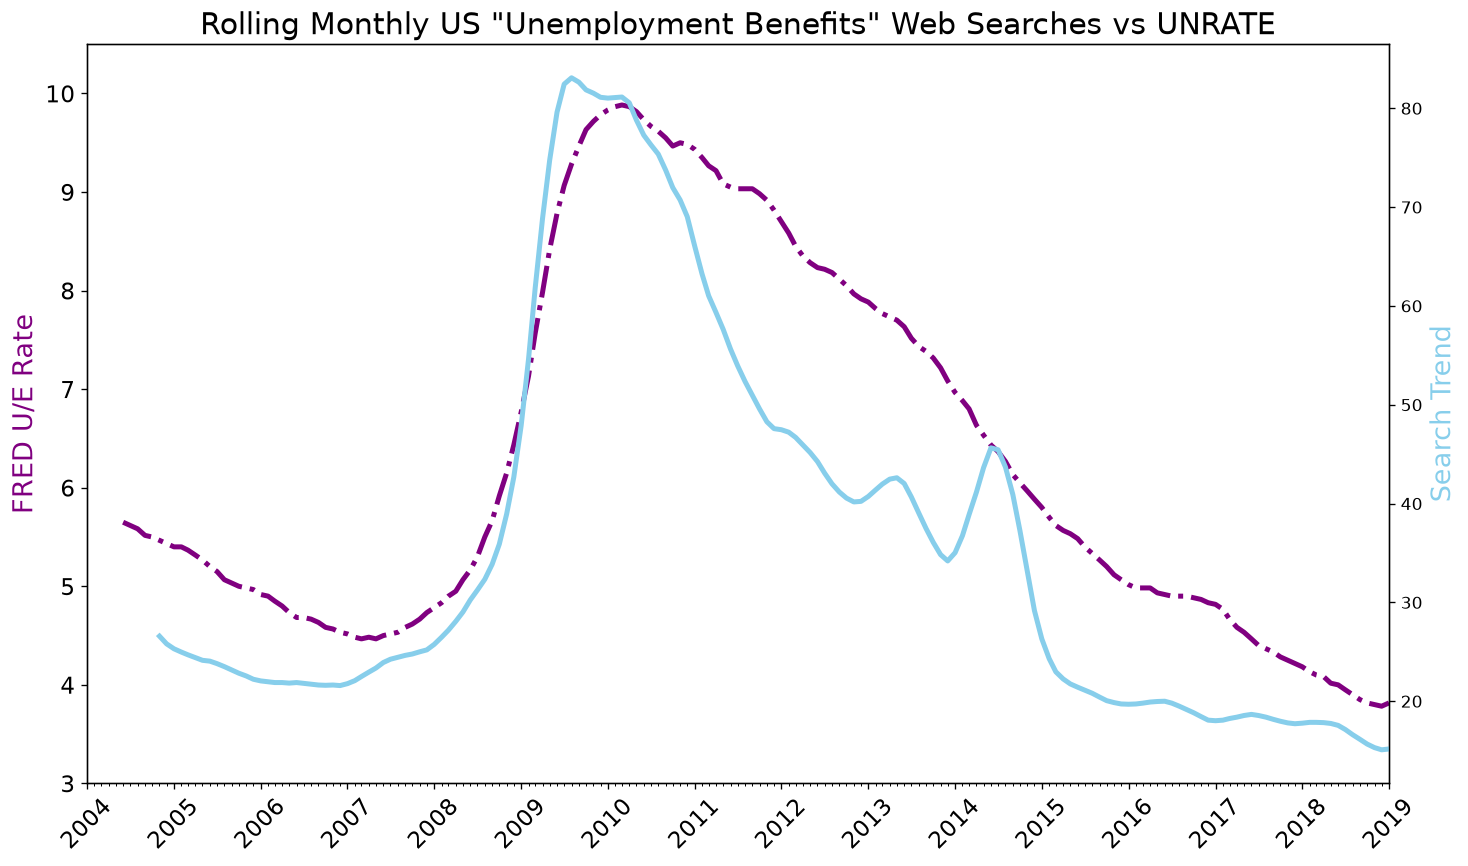

In [63]:
plt.figure(figsize=(14,8), dpi=120)
plt.title('Rolling Monthly US "Unemployment Benefits" Web Searches vs UNRATE', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)
 
ax1 = plt.gca()
ax2 = ax1.twinx()
 
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)
 
ax1.set_ylabel('FRED U/E Rate', color='purple', fontsize=16)
ax2.set_ylabel('Search Trend', color='skyblue', fontsize=16)
 
ax1.set_ylim(bottom=3, top=10.5)
ax1.set_xlim([df_unemployment.MONTH[0], df_unemployment.MONTH.max()])
 
# Calculate the rolling average over a 6 month window
roll_df = df_unemployment[['UE_BENEFITS_WEB_SEARCH', 'UNRATE']].rolling(window=6).mean()
 
ax1.plot(df_unemployment.MONTH, roll_df.UNRATE, 'purple', linewidth=3, linestyle='-.')
ax2.plot(df_unemployment.MONTH, roll_df.UE_BENEFITS_WEB_SEARCH, 'skyblue', linewidth=3)
 
plt.show()

### Including 2020 in Unemployment Charts

**Challenge**: Read the data in the 'UE Benefits Search vs UE Rate 2004-20.csv' into a DataFrame. Convert the MONTH column to Pandas Datetime objects and then plot the chart. What do you see?

In [64]:
df_unemployment_2020 = pd.read_csv('UE Benefits Search vs UE Rate 2004-20.csv')
df_unemployment_2020.MONTH = pd.to_datetime(df_unemployment_2020["MONTH"])

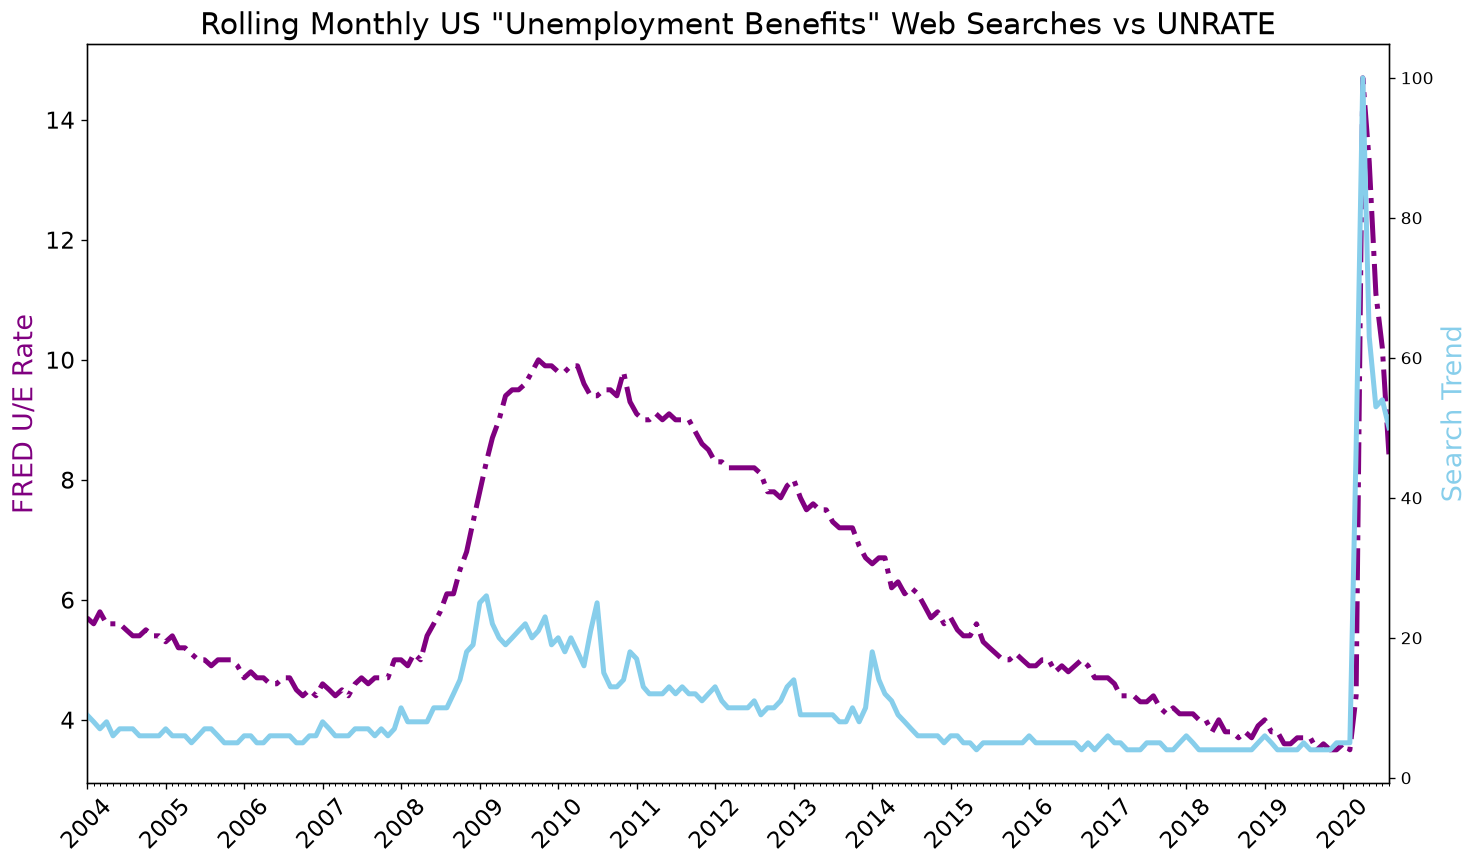

In [67]:
plt.figure(figsize=(14,8), dpi=120)
plt.title('Rolling Monthly US "Unemployment Benefits" Web Searches vs UNRATE', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)
 
ax1 = plt.gca()
ax2 = ax1.twinx()
 
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)
 
ax1.set_ylabel('FRED U/E Rate', color='purple', fontsize=16)
ax2.set_ylabel('Search Trend', color='skyblue', fontsize=16)
 
# ax1.set_ylim(bottom=3, top=10.5)
ax1.set_xlim([df_unemployment_2020.MONTH[0], df_unemployment_2020.MONTH.max()])
 
# Calculate the rolling average over a 6 month window
# roll_df = df_unemployment_2020[['UE_BENEFITS_WEB_SEARCH', 'UNRATE']].rolling(window=6).mean()
 
ax1.plot(df_unemployment_2020.MONTH, df_unemployment_2020.UNRATE, 'purple', linewidth=3, linestyle='-.')
ax2.plot(df_unemployment_2020.MONTH, df_unemployment_2020.UE_BENEFITS_WEB_SEARCH, 'skyblue', linewidth=3)
 
plt.show()

Google Trends does not give the actual number of searches. It rescales search interest within the date range you request.

For one download, Google effectively does this:

$$\text{Trend score} =
\frac{\text{search interest for that month}}
{\text{highest search interest in the selected period}}
\times 100$$

So, for the data ending in 2019:

The biggest month was in 2009.
Google assigns that month a score of 100.
Every other month is a percentage of that 2009 peak.
When you download the larger range that includes 2020:

Searches in March/April 2020 became the new biggest month.
Google assigns that month 100.
Google recomputes every older month relative to the 2020 peak.
Example with imaginary real search counts:

|Month|	Actual searches|	Score through 2019|	Score through 2020|
|-|-|-|-|
|2009| peak|	50,000|	100|	25|
|2020 |peak|	200,000	|Not included|	100|

The 2009 search count did not change. Only its displayed Google Trends score changed because the reference maximum changed from 50,000 to 200,000.

That is why the lines can look substantially different between the two CSV files. The unemployment-rate data from FRED is actual percentage data, so its values remain the same; only the Google Trends search column is rescaled.